# 03 — EDA: State Level Analysis

**Project:** Fentanyl Overdose Death (ODD) Analysis  
**Author:** Mitchell Yorkey 
**Last Updated:** 2026-04-10  

## Purpose
This notebook disaggregates the national synthetic opioid overdose trend to the state level. Key questions:
- Which states drove the national peak?
- Which states are declining fastest post-2023?
- Are there regional patterns that suggest geographic clustering of the crisis or the recovery?
- How does NYC compare to New York state — a first look at the urban concentration hypothesis.

## Important Methodological Note
All figures in this notebook use **raw death counts**, not per-capita rates. Raw counts favor large population states (California, Texas, Florida). Per-capita rates will be introduced in notebook 04 once population data is joined. Interpret state rankings here with that caveat in mind.

---
## 1. Imports and Load Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path().resolve().parent
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ── Load processed data ────────────────────────────────────────────────────
df = pd.read_csv(PROCESSED_DIR / "vsrr_overdose_latest.csv", parse_dates=['date'])
df['data_value'] = pd.to_numeric(df['data_value'], errors='coerce')

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Loaded 81,900 rows
Date range: 2015-01-01 to 2025-10-01


---
## 2. Define Constants and Base Filter

In [12]:
# ── Confirmed indicator string from notebook 01 ────────────────────────────
IND_SYNTHETIC = 'Synthetic opioids, excl. methadone (T40.4)'

# ── Peak date confirmed in notebook 02 ────────────────────────────────────
PEAK_DATE = pd.Timestamp('2023-06-01')

# ── Base filter: synthetic opioids, exclude national rollup ───────────────
df_states = (
    df[
        (df['indicator'] == IND_SYNTHETIC) &
        (df['state_name'] != 'United States')
    ]
    .copy()
    .sort_values(['state_name', 'date'])
    .dropna(subset=['data_value'])
)

print(f"States/jurisdictions in dataset: {df_states['state_name'].nunique()}")
print(f"Rows after filter: {len(df_states):,}")
print()
print("Jurisdictions included:")
print(sorted(df_states['state_name'].unique()))

States/jurisdictions in dataset: 51
Rows after filter: 5,195

Jurisdictions included:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'New York City', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


---
## 3. Figure 1 — Which States Had the Highest Death Counts at Peak?


In [13]:
# ── Get each state's value at or nearest to peak date ─────────────────────
def get_value_at_date(group, target_date):
    """Return the row closest to target_date for a state group."""
    idx = (group['date'] - target_date).abs().idxmin()
    return group.loc[idx]

df_at_peak = (
    df_states
    .groupby('state_name')
    .apply(get_value_at_date, target_date=PEAK_DATE)
    .reset_index(drop=True)
    [['state_name', 'date', 'data_value']]
    .sort_values('data_value', ascending=False)
)

print(f"States at peak — top 10:")
print(df_at_peak.head(10).to_string(index=False))

States at peak — top 10:
    state_name       date  data_value
    California 2023-06-01      7741.0
       Florida 2023-06-01      5140.0
          Ohio 2023-06-01      4038.0
North Carolina 2023-06-01      3419.0
     Tennessee 2023-06-01      2989.0
      Illinois 2023-06-01      2919.0
      New York 2023-06-01      2707.0
 New York City 2023-06-01      2637.0
         Texas 2023-06-01      2564.0
    Washington 2023-06-01      2433.0


C:\Users\Mitch\AppData\Local\Temp/ipykernel_28576/3465372911.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_states


In [14]:
# ── Get each state's individual peak (max data_value) ─────────────────────
df_at_peak = (
    df_states
    .loc[df_states.groupby('state_name')['data_value'].idxmax()]
    .reset_index(drop=True)
    [['state_name', 'date', 'data_value']]
    .rename(columns={'date': 'peak_date', 'data_value': 'peak_value'})
    .sort_values('peak_value', ascending=False)
)

print("Top 10 states by individual peak:")
print(df_at_peak.head(10).to_string(index=False))

Top 10 states by individual peak:
    state_name  peak_date  peak_value
    California 2023-10-01      8019.0
       Florida 2022-03-01      5624.0
          Ohio 2021-04-01      4420.0
North Carolina 2023-05-01      3448.0
     Tennessee 2023-06-01      2989.0
      Illinois 2022-12-01      2946.0
    Washington 2024-02-01      2744.0
      New York 2023-05-01      2720.0
 New York City 2023-06-01      2637.0
         Texas 2023-08-01      2607.0


Figure 1 saved


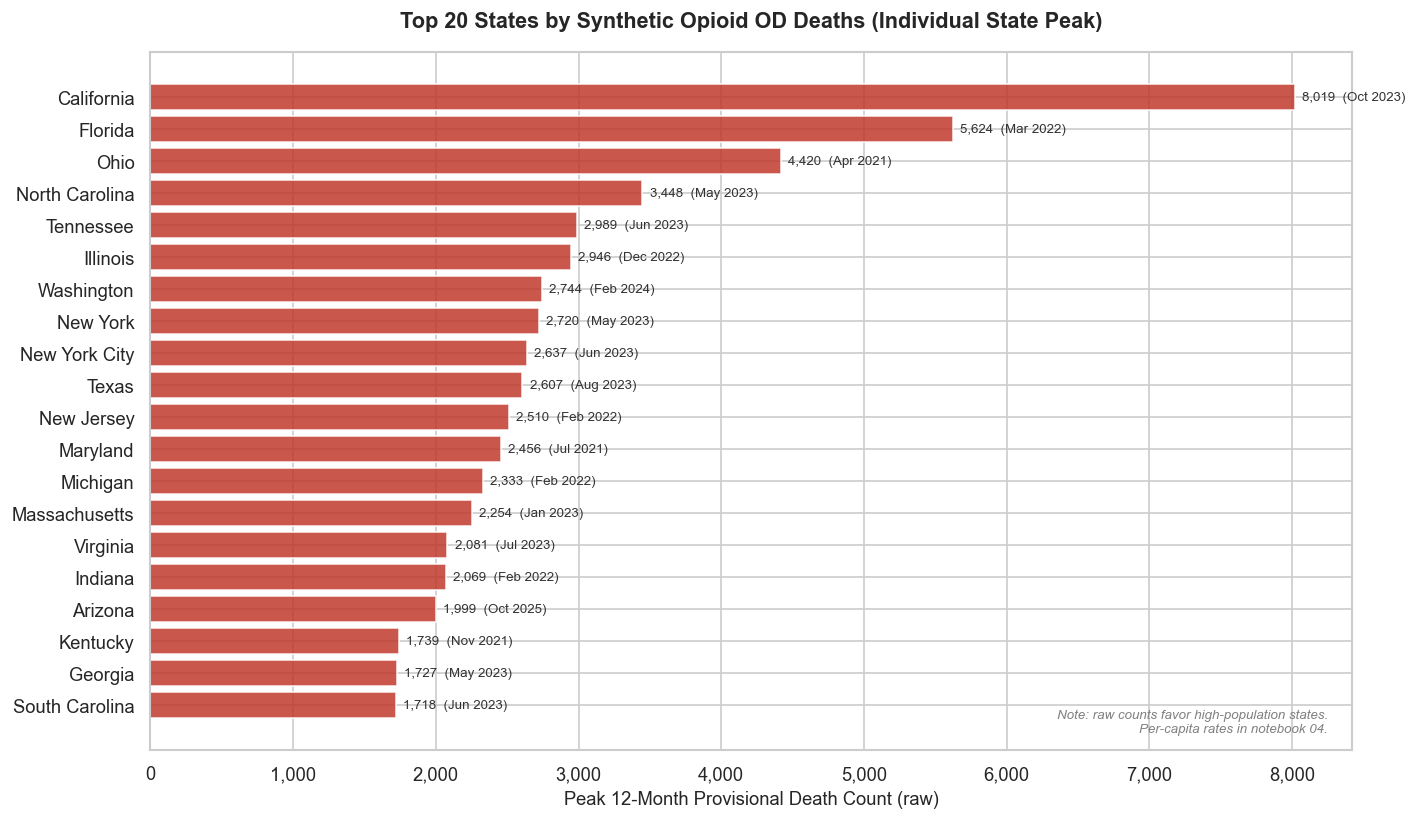

In [15]:
top20_peak = df_at_peak.head(20)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top20_peak['state_name'][::-1],
    top20_peak['peak_value'][::-1],
    color='#c0392b', alpha=0.85
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(
    'Top 20 States by Synthetic Opioid OD Deaths (Individual State Peak)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Peak 12-Month Provisional Death Count (raw)', fontsize=11)

# Label each bar with value AND the month it peaked
for bar, (_, row) in zip(bars, top20_peak[::-1].iterrows()):
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['peak_value']):,}  ({row['peak_date'].strftime('%b %Y')})",
        va='center', fontsize=8, color='#333333'
    )

ax.text(
    0.98, 0.02,
    'Note: raw counts favor high-population states.\nPer-capita rates in notebook 04.',
    transform=ax.transAxes, fontsize=8, color='gray',
    ha='right', va='bottom', style='italic'
)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig1_states_at_peak.png', dpi=150)
print('Figure 1 saved')
plt.show()

---
## 4. Figure 2 — Which States Are Declining Fastest?

We calculate the percent change from peak to the most recent data point 
for each state. A larger negative number = faster decline.

In [17]:
# ── Get each state's latest value ─────────────────────────────────────────
LATEST_DATE = df_states['date'].max()

df_latest = (
    df_states
    .groupby('state_name')
    .apply(get_value_at_date, target_date=LATEST_DATE)
    .reset_index(drop=True)
    [['state_name', 'date', 'data_value']]
    .rename(columns={'data_value': 'latest_value', 'date': 'latest_date'})
)
# ── Merge peak and latest ──────────────────────────────────────────────────
df_change = pd.merge(
    df_at_peak[['state_name', 'peak_value']],
    df_latest[['state_name', 'latest_value']],
    on='state_name'
)
# ── Merge peak and latest, calculate % change ──────────────────────────────
df_change['pct_change'] = (
    (df_change['latest_value'] - df_change['peak_value']) / df_change['peak_value']
) * 100

df_change['raw_change'] = df_change['latest_value'] - df_change['peak_value']

df_change = df_change.sort_values('raw_change')

print("States with largest raw decline from individual peak:")
print(df_change.head(10).to_string(index=False))
print()
print("States with smallest decline or increase from individual peak:")
print(df_change.tail(10).to_string(index=False))

States with largest raw decline from individual peak:
    state_name  peak_value  latest_value  pct_change  raw_change
       Florida      5624.0        1955.0  -65.238265     -3669.0
    California      8019.0        4625.0  -42.324479     -3394.0
          Ohio      4420.0        1389.0  -68.574661     -3031.0
North Carolina      3448.0        1449.0  -57.975638     -1999.0
      Illinois      2946.0        1142.0  -61.235574     -1804.0
      New York      2720.0         920.0  -66.176471     -1800.0
     Tennessee      2989.0        1313.0  -56.072265     -1676.0
      Maryland      2456.0         958.0  -60.993485     -1498.0
      Michigan      2333.0         870.0  -62.708958     -1463.0
    New Jersey      2510.0        1071.0  -57.330677     -1439.0

States with smallest decline or increase from individual peak:
  state_name  peak_value  latest_value  pct_change  raw_change
  New Mexico       672.0         564.0  -16.071429      -108.0
        Utah       353.0         254.0  -

C:\Users\Mitch\AppData\Local\Temp/ipykernel_28576/410736124.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_states


Figure 2 saved


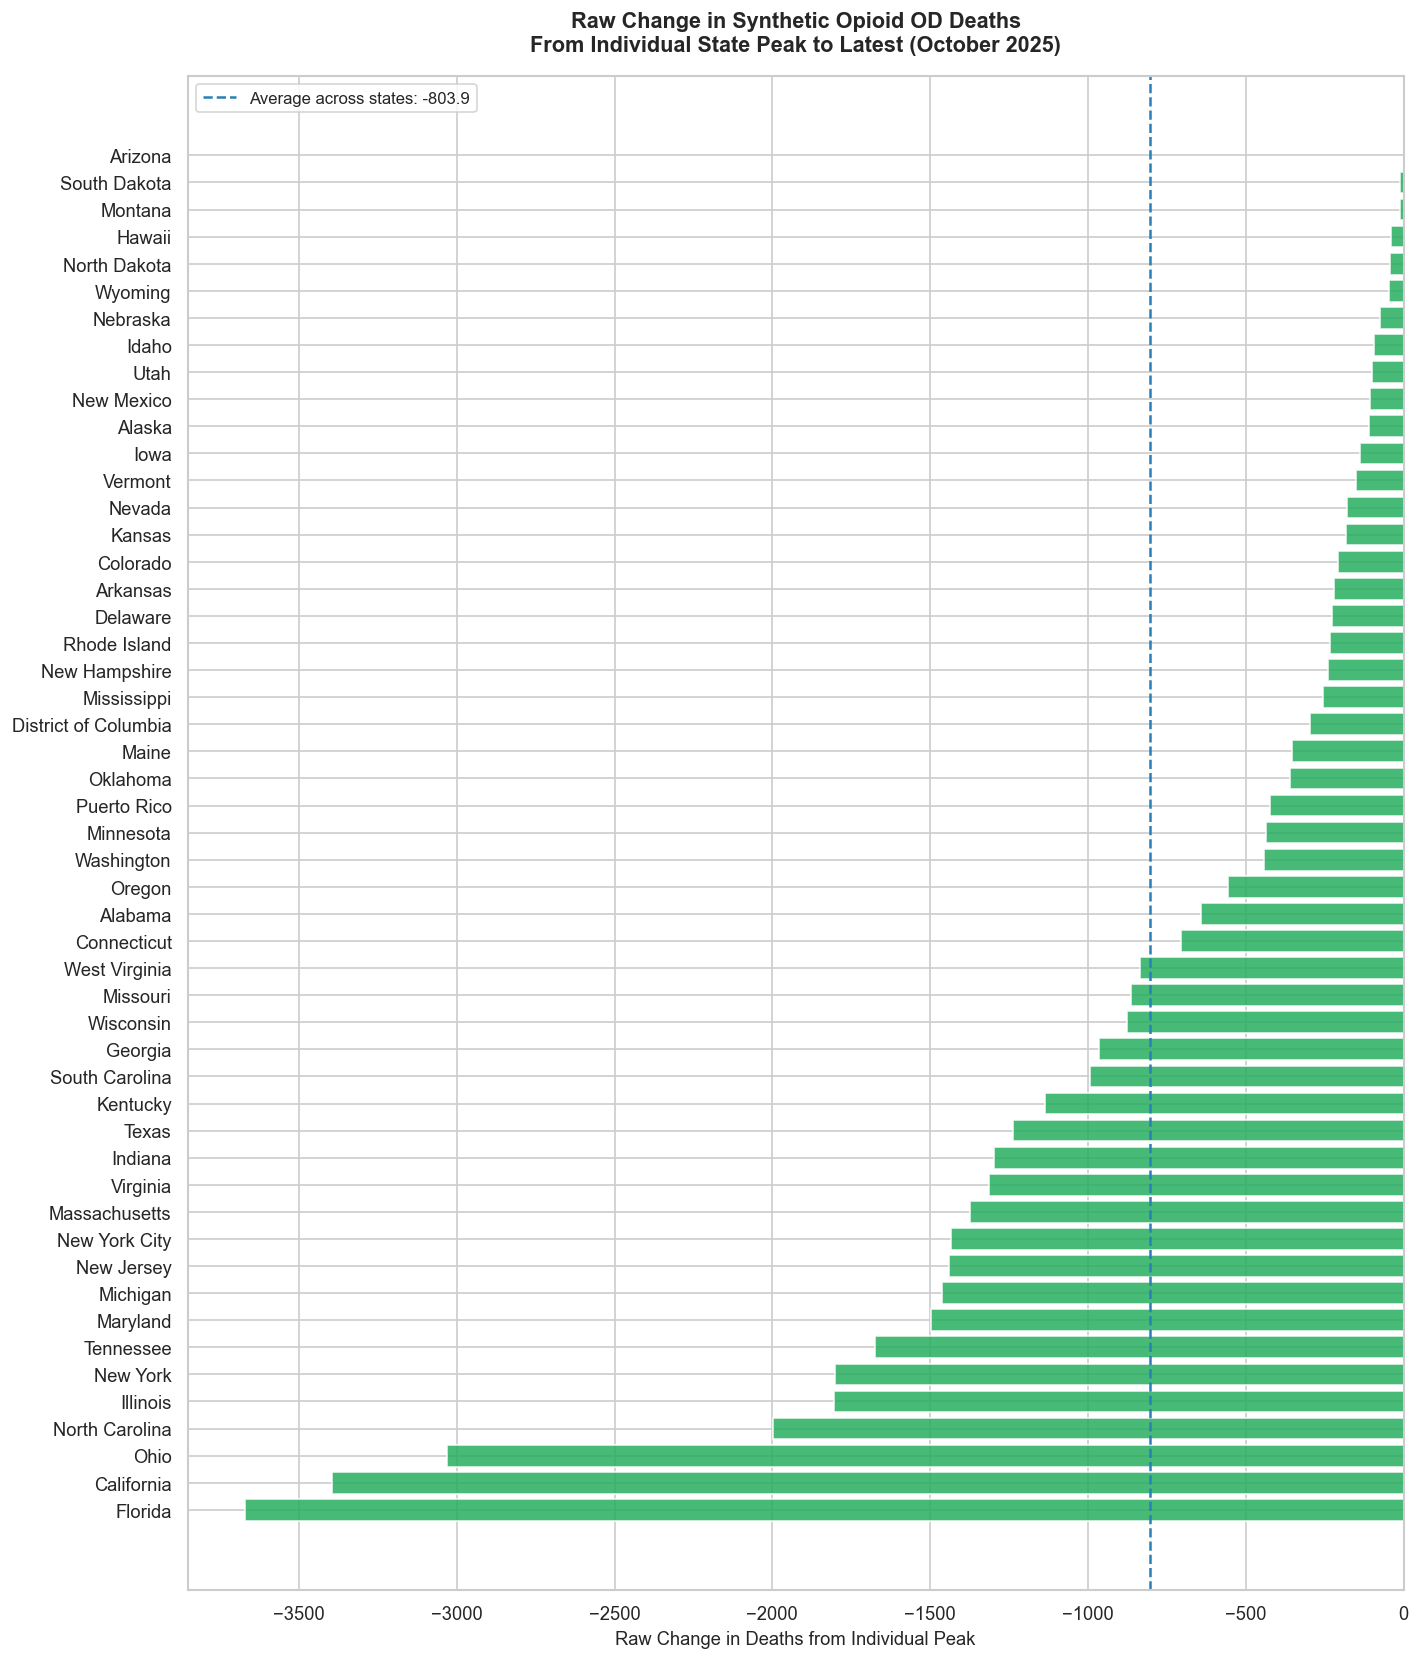

In [19]:
# ── Bar chart: % change from peak to latest, all states ───────────────────
fig, ax = plt.subplots(figsize=(12, 14))

colors = ['#27ae60' if x < 0 else '#c0392b' for x in df_change['raw_change']]

ax.barh(
    df_change['state_name'],
    df_change['raw_change'],
    color=colors,
    alpha=0.85
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(
    f'Raw Change in Synthetic Opioid OD Deaths\nFrom Individual State Peak to Latest ({LATEST_DATE.strftime("%B %Y")})',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Raw Change in Deaths from Individual Peak', fontsize=11)
ax.set_ylabel('')

# Add national average line
national_change = df_change['raw_change'].mean()
ax.axvline(
    national_change, color='#2980b9',
    linestyle='--', linewidth=1.5,
    label=f'Average across states: {national_change:.1f}'
)
ax.legend(fontsize=10)



plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig2_state_decline_rates.png', dpi=150)
print('Figure 2 saved')
plt.show()

---
## 5. Figure 3 — Regional Trends Over Time

Group states into Census Bureau regions to identify geographic patterns 
in both the rise and the decline.

In [20]:
# ── Census region mapping ──────────────────────────────────────────────────
REGIONS = {
    'Northeast': [
        'Connecticut', 'Maine', 'Massachusetts', 'New Hampshire',
        'Rhode Island', 'Vermont', 'New Jersey', 'New York', 'Pennsylvania',
        'New York City'
    ],
    'Midwest': [
        'Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin',
        'Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska',
        'North Dakota', 'South Dakota'
    ],
    'South': [
        'Delaware', 'Florida', 'Georgia', 'Maryland', 'North Carolina',
        'South Carolina', 'Virginia', 'District of Columbia', 'West Virginia',
        'Alabama', 'Kentucky', 'Mississippi', 'Tennessee', 'Arkansas',
        'Louisiana', 'Oklahoma', 'Texas'
    ],
    'West': [
        'Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico',
        'Utah', 'Wyoming', 'Alaska', 'California', 'Hawaii', 'Oregon', 'Washington'
    ]
}

# Invert mapping: state -> region
state_to_region = {state: region for region, states in REGIONS.items() for state in states}
df_states['region'] = df_states['state_name'].map(state_to_region)

# Check unmapped states
unmapped = df_states[df_states['region'].isna()]['state_name'].unique()
if len(unmapped) > 0:
    print(f"Unmapped jurisdictions (excluded from regional analysis): {unmapped}")
else:
    print("All states mapped to regions ✓")

# ── Aggregate by region and date ───────────────────────────────────────────
df_regional = (
    df_states.dropna(subset=['region'])
    .groupby(['region', 'date'])['data_value']
    .sum()
    .reset_index()
    .sort_values(['region', 'date'])
)

print(f"\nRegional data shape: {df_regional.shape}")
df_regional.groupby('region')['data_value'].max()

Unmapped jurisdictions (excluded from regional analysis): ['Puerto Rico']

Regional data shape: (520, 3)


region
Midwest      16024.0
Northeast    12677.0
South        27957.0
West         17594.0
Name: data_value, dtype: float64

Figure 3 saved


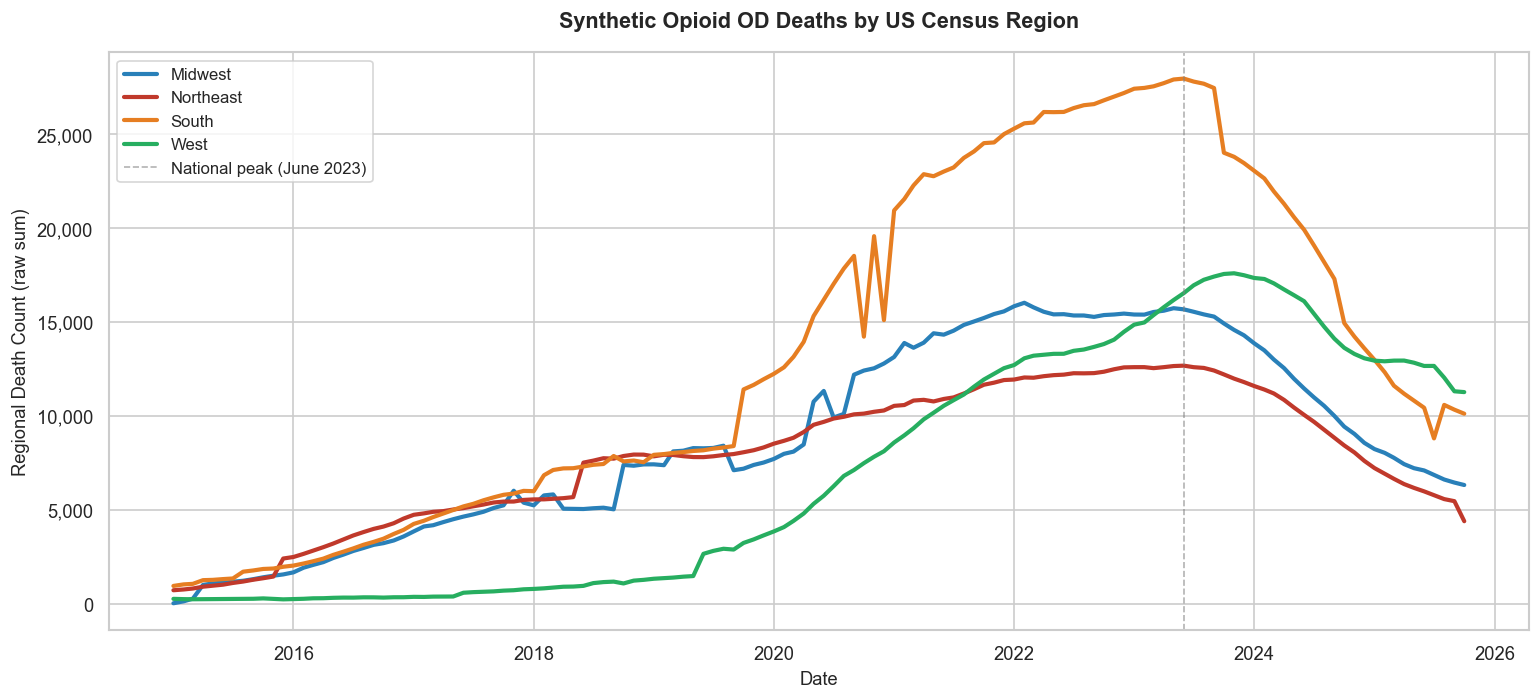

In [22]:
region_colors = {
    'Northeast': '#c0392b',
    'South':     '#e67e22',
    'Midwest':   '#2980b9',
    'West':      '#27ae60'
}

fig, ax = plt.subplots(figsize=(13, 6))

for region, group in df_regional.groupby('region'):
    ax.plot(
        group['date'].to_numpy(), group['data_value'].to_numpy(),
        color=region_colors[region],
        linewidth=2.5, label=region
    )

ax.axvline(
    PEAK_DATE, color='gray', linestyle='--',
    alpha=0.6, linewidth=1, label=f'National peak ({PEAK_DATE.strftime("%B %Y")})'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(
    'Synthetic Opioid OD Deaths by US Census Region',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Regional Death Count (raw sum)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig3_regional_trends.png', dpi=150)
print('Figure 3 saved')
plt.show()

---
## 6. Figure 4 — NYC vs. New York State

NYC is reported separately in this dataset — a rare opportunity to compare 
a major urban center directly against its surrounding state.
This is a first look at the urban concentration hypothesis.

In [23]:
df_nyc = (
    df_states[df_states['state_name'] == 'New York City']
    .sort_values('date')
    .dropna(subset=['data_value'])
)
df_ny = (
    df_states[df_states['state_name'] == 'New York']
    .sort_values('date')
    .dropna(subset=['data_value'])
)

# Merge — note: NY State and NYC are mutually exclusive in CDC data
df_ny_compare = pd.merge(
    df_nyc[['date', 'data_value']].rename(columns={'data_value': 'nyc'}),
    df_ny[['date', 'data_value']].rename(columns={'data_value': 'ny_state'}),
    on='date', how='inner'
)

# Combined = NYC + rest of NY State
df_ny_compare['combined'] = df_ny_compare['nyc'] + df_ny_compare['ny_state']
df_ny_compare['nyc_pct_of_combined'] = (
    df_ny_compare['nyc'] / df_ny_compare['combined']
) * 100

print("NYC vs NY State — recent months:")
print(df_ny_compare[['date', 'nyc', 'ny_state', 'combined', 'nyc_pct_of_combined']].tail(10).to_string(index=False))

NYC vs NY State — recent months:
      date    nyc  ny_state  combined  nyc_pct_of_combined
2024-12-01 1619.0    1554.0    3173.0            51.024267
2025-01-01 1552.0    1449.0    3001.0            51.716095
2025-02-01 1473.0    1362.0    2835.0            51.957672
2025-03-01 1416.0    1269.0    2685.0            52.737430
2025-04-01 1368.0    1184.0    2552.0            53.605016
2025-05-01 1322.0    1119.0    2441.0            54.158132
2025-06-01 1274.0    1082.0    2356.0            54.074703
2025-07-01 1257.0    1029.0    2286.0            54.986877
2025-08-01 1217.0     967.0    2184.0            55.723443
2025-09-01 1220.0     920.0    2140.0            57.009346


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

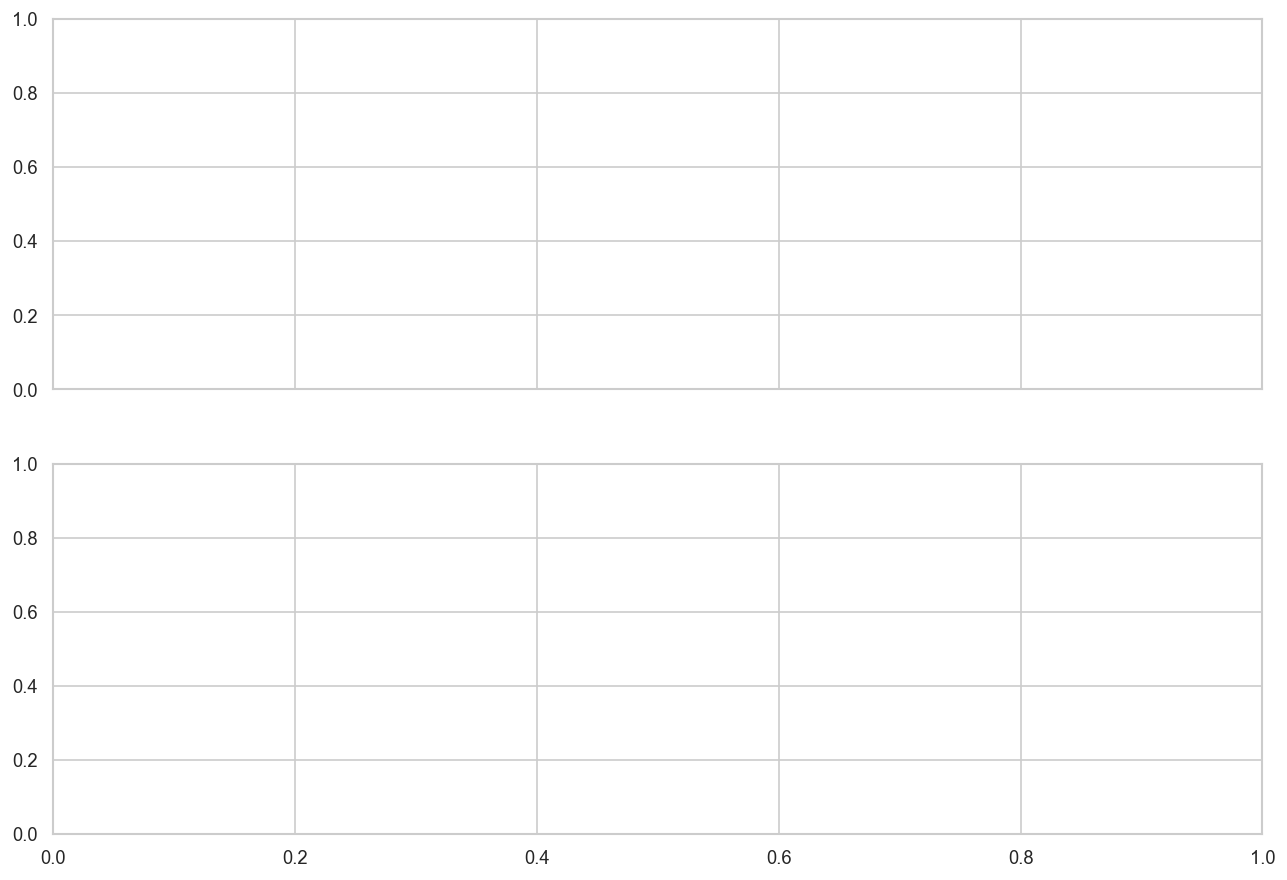

In [24]:
pythonfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Top panel: raw counts ──────────────────────────────────────────────────
ax1.plot(df_nyc['date'], df_nyc['data_value'],
         color='#c0392b', linewidth=2, label='New York City')
ax1.plot(df_ny['date'], df_ny['data_value'],
         color='#2980b9', linewidth=2, label='Rest of New York State')
ax1.axvline(PEAK_DATE, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylabel('Death Count (raw)', fontsize=10)
ax1.set_title(
    'NYC vs. Rest of New York State — Synthetic Opioid OD Deaths\n(Reported as separate mutually exclusive jurisdictions in CDC data)',
    fontsize=12, fontweight='bold', pad=15
)
ax1.legend(fontsize=10)

# ── Bottom panel: NYC as % of combined ────────────────────────────────────
ax2.plot(
    df_ny_compare['date'], df_ny_compare['nyc_pct_of_combined'],
    color='#8e44ad', linewidth=2, label='NYC as % of NYC + Rest of NY State'
)
ax2.axvline(PEAK_DATE, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_ylabel('NYC as % of Combined Total', fontsize=10)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig4_nyc_vs_ny_state.png', dpi=150)
print('Figure 4 saved')
plt.show()

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

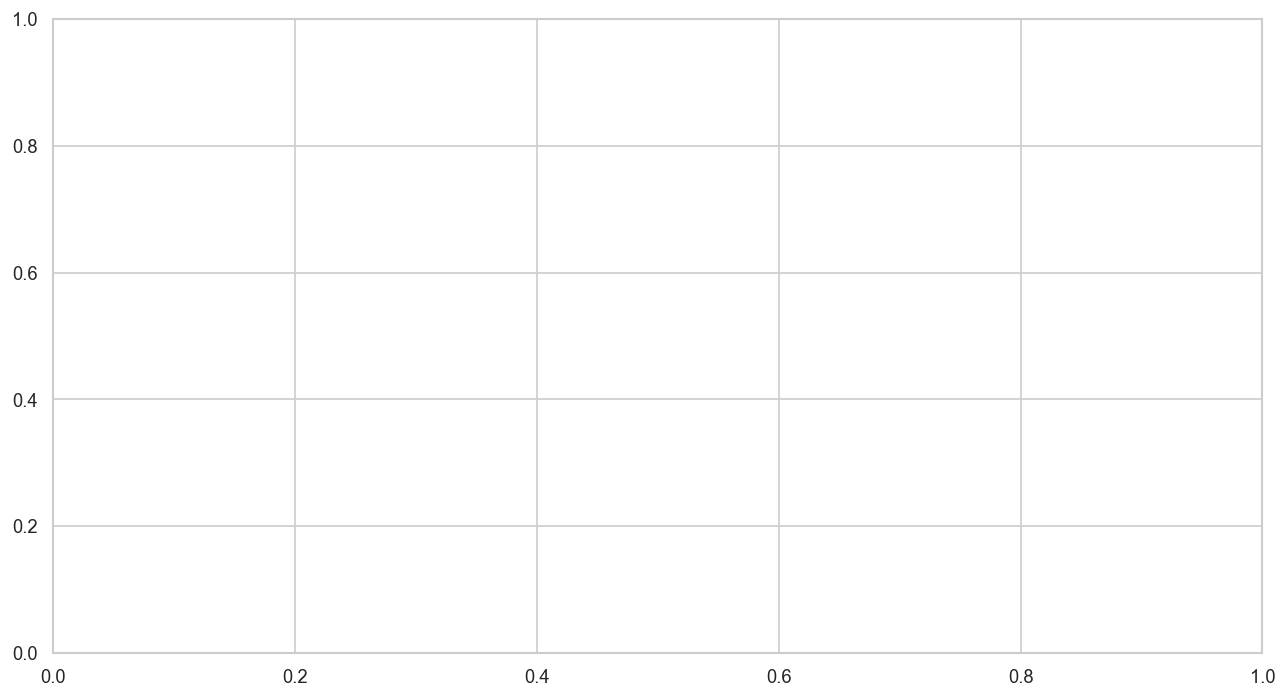

In [25]:
south_states = REGIONS['South']

df_south = (
    df_states[df_states['state_name'].isin(south_states)]
    .sort_values(['state_name', 'date'])
)

fig, ax = plt.subplots(figsize=(13, 7))

for state, group in df_south.groupby('state_name'):
    ax.plot(group['date'], group['data_value'], linewidth=1.5, label=state)

ax.axvline(PEAK_DATE, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Synthetic Opioid OD Deaths — South Region States', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Death Count (raw)', fontsize=11)
ax.legend(fontsize=8, ncol=2, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig5_south_states.png', dpi=150)
print('Figure 5 saved')
plt.show()

In [26]:
south_start_dates = (
    df_south.groupby('state_name')['date']
    .min()
    .sort_values()
    .reset_index()
)
print("South state reporting start dates:")
print(south_start_dates.to_string(index=False))
print()
south_date_range = (
    df_south.groupby('state_name')['date']
    .agg(['min', 'max', 'count'])
    .sort_values('min')
    .reset_index()
)
south_date_range.columns = ['state_name', 'first_report', 'last_report', 'num_months']
print(south_date_range.to_string(index=False))

South state reporting start dates:
          state_name       date
District of Columbia 2015-01-01
            Maryland 2015-01-01
      North Carolina 2015-01-01
            Oklahoma 2015-01-01
      South Carolina 2015-01-01
            Virginia 2015-01-01
       West Virginia 2015-01-01
           Tennessee 2015-04-01
             Georgia 2015-08-01
            Kentucky 2018-02-01
            Delaware 2018-03-01
               Texas 2018-09-01
         Mississippi 2019-02-01
             Florida 2019-10-01
            Arkansas 2021-08-01
             Alabama 2022-04-01

          state_name first_report last_report  num_months
District of Columbia   2015-01-01  2025-10-01         130
            Maryland   2015-01-01  2025-10-01         130
      North Carolina   2015-01-01  2025-06-01         114
            Oklahoma   2015-01-01  2025-02-01         122
      South Carolina   2015-01-01  2025-10-01         130
            Virginia   2015-01-01  2025-10-01         130
       West Vi

Figure 6 saved


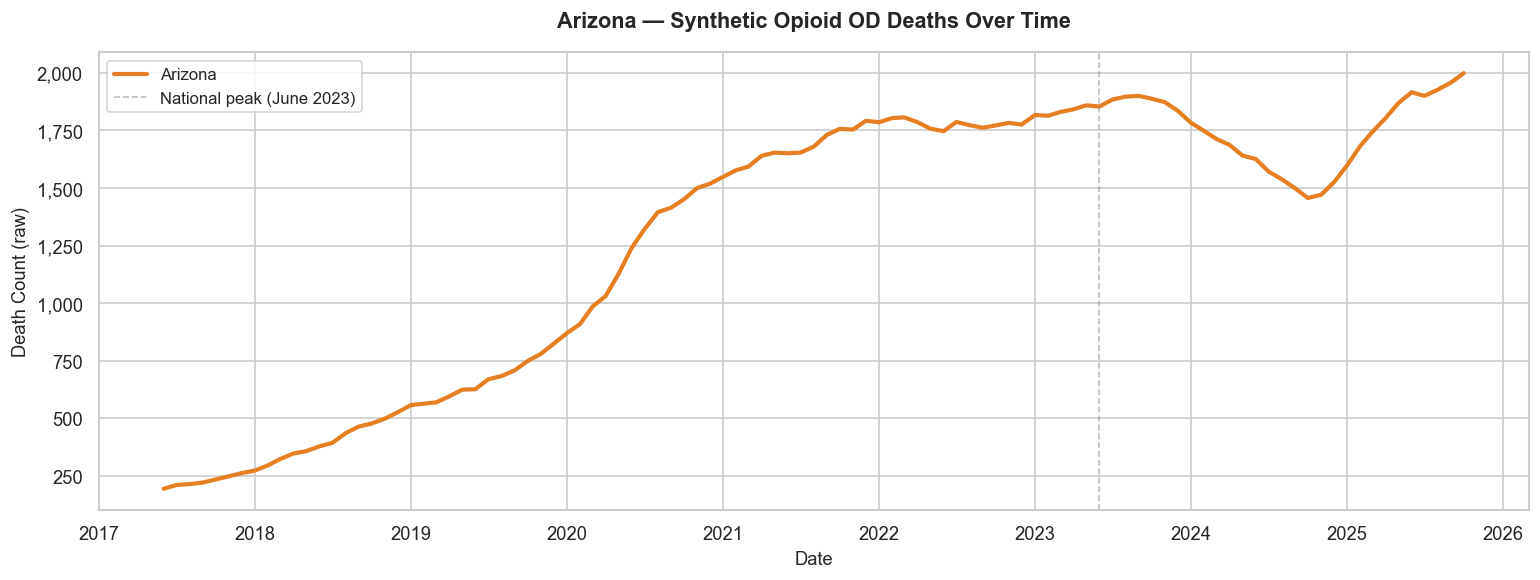

In [28]:
df_az = (
    df_states[df_states['state_name'] == 'Arizona']
    .sort_values('date')
    .dropna(subset=['data_value'])
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_az['date'].to_numpy(), df_az['data_value'].to_numpy(),
        color='#e67e22', linewidth=2.5, label='Arizona')
ax.axvline(PEAK_DATE, color='gray', linestyle='--', alpha=0.5, linewidth=1,
           label=f'National peak ({PEAK_DATE.strftime("%B %Y")})')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Arizona — Synthetic Opioid OD Deaths Over Time', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Death Count (raw)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_fig6_arizona.png', dpi=150)
print('Figure 6 saved')
plt.show()

---
## 7. Observations and Next Steps

### Observations

*(Fill in after running cells above)*

**Figure 1 — States at peak (raw counts):**
- [ ] Top 3 states by raw count at peak: __, __, __
- [ ] Notable: large population states dominate — per-capita ranking likely differs

**Figure 2 — Decline rates by state:**
- [ ] Fastest declining states: __, __, __
- [ ] Any states showing increases rather than declines?
- [ ] Average decline across states: __%

**Figure 3 — Regional trends:**
- [ ] Which region peaked highest in raw terms?
- [ ] Did all regions peak at roughly the same time or were there leads/lags?
- [ ] Which region is declining fastest post-2023?

**Figure 4 — NYC vs NY State:**
- [ ] NYC accounts for roughly __% of NY State deaths
- [ ] Has that share been [growing/shrinking/stable] over time?
- [ ] Does NYC show a different trajectory than the state overall?

### Next Steps → Notebook 04
- Bring in US Census population data to convert raw counts to per-capita rates
- Per-capita ranking will likely surface smaller states (WV, NH, OH) as the true hotspots
- Begin pulling external data sources to test hypotheses H1-H4:
  - DEA purity/seizure data (H1 — supply shock)
  - Naloxone distribution data (H4 — harm reduction)
  - Buprenorphine prescribing rates (H5 — treatment access)